# Notebook 2. Measures of the phloem width

This notebook aims at measuring the phloem width from images observed in the rdial direction, that is, crossing the cane longitudinally and through its central axis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import segmentation_tools as seg

%load_ext autoreload
%autoreload 2

First, let us load the image of interest.

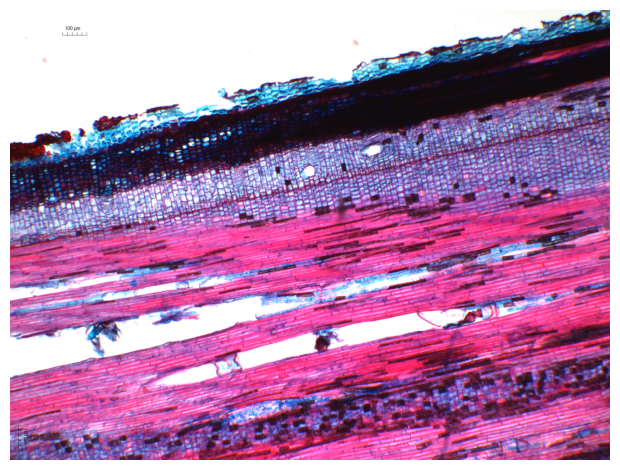

In [2]:
image = tifffile.imread('./input images/Sample 1.1-C-Rie-I-Month 3-x4.tif')
plt.imshow(image)
plt.axis('off')
plt.tight_layout()

Then, run the segmentation code to produce the segmentation mask and estimated width

In [3]:
median_width,msk_phloem = seg.get_phloem_median_width(image)

In [4]:
# Introducting the physical scales to provide a measure in µm
pix_per_um_x4 = 0.84
um_per_pix_x4 = 1/pix_per_um_x4

phloem_width_um = median_width * um_per_pix_x4

print('Median width of the phloem on this sample : %.2f µm.'%phloem_width_um)

Median width of the phloem on this sample : 171.69 µm.


Finally, summarize the result in one image.

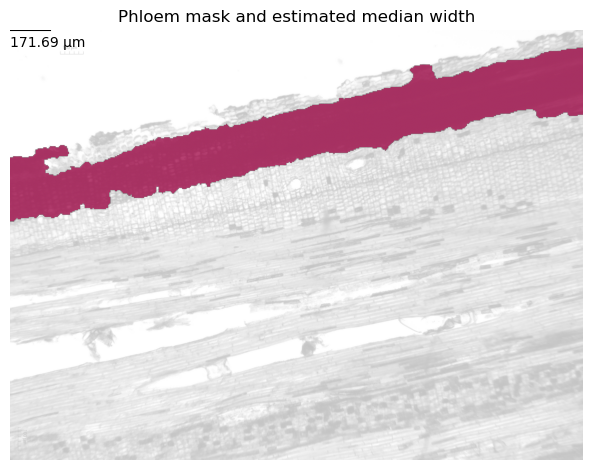

In [5]:
import segmentation_tools as seg
seg.display(image,msk_phloem.astype(float))
plt.plot([0,phloem_width_um/um_per_pix_x4],[0,0],'k')
plt.text(0,60,'%.2f µm'%phloem_width_um)
plt.title('Phloem mask and estimated median width')
plt.tight_layout()

Remark: while the segmentation seems spurious in some areas, this does not prevent an adequate estimate of the phloem width, as the median estimator is used.